# Project 10: AI-Based Image Restoration and Super-Resolution

This notebook implements:
- **CNN-based Autoencoder** for image denoising and artifact removal
- **SRGAN** for high-resolution image reconstruction
- **Perceptual Loss** using VGG19 features
- Datasets: **DIV2K** (super-resolution) and **CelebA** (denoising)
- Framework: **PyTorch** + **OpenCV**

In [1]:
# ── Install PyTorch for T4 GPU (sm_75, CUDA 12.x) ───────────────────────────
# Switch your Kaggle accelerator to T4 GPU — the P100 (sm_60) is not
# supported by any PyTorch build newer than 1.x.
import subprocess, sys
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q', '--upgrade',
    'torch', 'torchvision',
    '--index-url', 'https://download.pytorch.org/whl/cu121'
], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'opencv-python-headless', 'tqdm'], check=True)
print('Installation complete — restart the kernel now before running further cells.')

Installation complete — restart the kernel now before running further cells.


In [2]:
import os
import math
import random
import numpy as np
from math import floor
from tqdm import tqdm
from glob import glob

import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.utils import save_image
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cuda


## Hyper-parameters

In [3]:
# ── Shared ───────────────────────────────────────────────────────────────────
BATCH_SIZE          = 16
NUM_WORKERS         = 2

# ── Denoising autoencoder ────────────────────────────────────────────────────
DENOISE_EPOCHS      = 20
DENOISE_LR          = 1e-3
NOISE_STD           = 0.1          # Gaussian noise σ added to inputs

# ── SRGAN ────────────────────────────────────────────────────────────────────
SR_EPOCHS           = 50
SR_LR               = 1e-4
SR_LR_D             = 2e-5   # discriminator LR = 1/5 of generator LR (prevents dominance)
UPSCALE_FACTOR      = 4
HR_CROP_SIZE        = 128          # HR patch; LR patch = HR / UPSCALE_FACTOR

# Perceptual loss weights
LAMBDA_CONTENT      = 1.0
LAMBDA_ADV          = 5e-3   # raised from 1e-3 — gives generator stronger adversarial signal

# ── Dataset paths (DIV2K on Kaggle) ─────────────────────────────────────────
DIV2K_TRAIN_HR = '/kaggle/input/datasets/joe1995/div2k-dataset/DIV2K_train_HR'
DIV2K_VALID_HR = '/kaggle/input/datasets/joe1995/div2k-dataset/DIV2K_valid_HR'

# CelebA — adjust to your Kaggle dataset path if different
CELEBA_DIR     = '/kaggle/input/celeba-dataset/img_align_celeba'

TRAIN_VAL_SPLIT = 0.9

---
## Part 1 — Image Denoising with CNN Autoencoder (CelebA)

In [4]:
# ── CelebA denoising dataset ──────────────────────────────────────────────────
class CelebADenoiseDataset(Dataset):
    """
    Loads CelebA face images, adds Gaussian noise to create degraded inputs,
    and returns (noisy_image, clean_image) pairs for supervised denoising.
    Uses OpenCV for fast image I/O and resizing.
    """
    def __init__(self, img_dir: str, noise_std: float = 0.1,
                 img_size: int = 64, max_samples: int = 10000):
        self.paths     = sorted(glob(os.path.join(img_dir, '*.jpg')))[:max_samples]
        self.noise_std = noise_std
        self.img_size  = img_size
        self.to_tensor = transforms.ToTensor()          # HWC uint8 → CHW float [0,1]

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        # OpenCV: read BGR → convert to RGB
        bgr  = cv2.imread(self.paths[idx])
        rgb  = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        rgb  = cv2.resize(rgb, (self.img_size, self.img_size),
                          interpolation=cv2.INTER_AREA)
        clean = self.to_tensor(rgb)                     # [0, 1] float32
        noisy = (clean + torch.randn_like(clean) * self.noise_std).clamp(0, 1)
        return noisy, clean


if os.path.isdir(CELEBA_DIR):
    full_ds   = CelebADenoiseDataset(CELEBA_DIR, noise_std=NOISE_STD)
    n_train   = int(len(full_ds) * TRAIN_VAL_SPLIT)
    train_denoise, val_denoise = torch.utils.data.random_split(
        full_ds, [n_train, len(full_ds) - n_train])
    train_denoise_loader = DataLoader(train_denoise, batch_size=BATCH_SIZE,
                                      shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
    val_denoise_loader   = DataLoader(val_denoise,   batch_size=BATCH_SIZE,
                                      shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    print(f'CelebA — train: {len(train_denoise)} | val: {len(val_denoise)}')
else:
    print(f'CelebA not found at {CELEBA_DIR} — skipping denoising section.')
    train_denoise_loader = val_denoise_loader = None

CelebA not found at /kaggle/input/celeba-dataset/img_align_celeba — skipping denoising section.


In [5]:
# ── CNN Autoencoder architecture ──────────────────────────────────────────────
class ConvAutoencoder(nn.Module):
    """
    Symmetric encoder-decoder with skip connections for image denoising.
    Encoder compresses spatial resolution; decoder reconstructs via transposed
    convolutions. Sigmoid output keeps pixel values in [0, 1].
    """
    def __init__(self, in_channels: int = 3):
        super().__init__()
        # ── Encoder ──────────────────────────────────────────────────────────
        self.enc1 = self._conv_block(in_channels, 32)   # 64 → 32
        self.enc2 = self._conv_block(32, 64)            # 32 → 16
        self.enc3 = self._conv_block(64, 128)           # 16 → 8
        self.pool = nn.MaxPool2d(2, 2)

        # ── Bottleneck ───────────────────────────────────────────────────────
        self.bottleneck = self._conv_block(128, 256, pool=False)

        # ── Decoder ──────────────────────────────────────────────────────────
        self.up3  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = self._conv_block(256, 128, pool=False)  # 256 = skip + up
        self.up2  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = self._conv_block(128, 64,  pool=False)
        self.up1  = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = self._conv_block(64, 32,   pool=False)

        self.out_conv = nn.Conv2d(32, in_channels, 1)

    @staticmethod
    def _conv_block(in_ch, out_ch, pool=True):
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        return nn.Sequential(*layers)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        # Bottleneck
        b  = self.bottleneck(self.pool(e3))
        # Decoder with skip connections
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return torch.sigmoid(self.out_conv(d1))


autoencoder = ConvAutoencoder().to(DEVICE)
print('Autoencoder parameters:', sum(p.numel() for p in autoencoder.parameters()))

Autoencoder parameters: 1928483


In [6]:
# ── Train denoising autoencoder ───────────────────────────────────────────────
def train_denoiser(model, train_loader, val_loader, epochs, lr):
    optimizer  = optim.Adam(model.parameters(), lr=lr)
    scheduler  = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    criterion  = nn.MSELoss()
    history    = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        # ── Training ─────────────────────────────────────────────────────────
        model.train()
        running = 0.0
        for noisy, clean in tqdm(train_loader, desc=f'Epoch {epoch}/{epochs} [train]'):
            noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
            optimizer.zero_grad()
            output = model(noisy)
            loss   = criterion(output, clean)
            loss.backward()
            optimizer.step()
            running += loss.item()
        train_loss = running / len(train_loader)

        # ── Validation ───────────────────────────────────────────────────────
        model.eval()
        running = 0.0
        with torch.no_grad():
            for noisy, clean in val_loader:
                noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
                running += criterion(model(noisy), clean).item()
        val_loss = running / len(val_loader)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        scheduler.step()
        print(f'  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}')

    return history


if train_denoise_loader is not None:
    denoise_history = train_denoiser(
        autoencoder, train_denoise_loader, val_denoise_loader,
        epochs=DENOISE_EPOCHS, lr=DENOISE_LR)
else:
    denoise_history = None
    print('Skipped — no CelebA data.')

Skipped — no CelebA data.


In [7]:
# ── Plot denoising training curves ────────────────────────────────────────────
if denoise_history:
    plt.figure(figsize=(8, 4))
    plt.plot(denoise_history['train_loss'], label='Train Loss', marker='o')
    plt.plot(denoise_history['val_loss'],   label='Val Loss',   marker='o')
    plt.title('Denoising Autoencoder — MSE Loss')
    plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.tight_layout()
    plt.show()

In [8]:
# ── Visualise denoising results ───────────────────────────────────────────────
if train_denoise_loader is not None:
    autoencoder.eval()
    noisy_batch, clean_batch = next(iter(val_denoise_loader))
    with torch.no_grad():
        restored = autoencoder(noisy_batch.to(DEVICE)).cpu()

    fig, axes = plt.subplots(3, 4, figsize=(14, 9))
    for i in range(4):
        axes[0, i].imshow(noisy_batch[i].permute(1, 2, 0))
        axes[0, i].set_title('Noisy'); axes[0, i].axis('off')
        axes[1, i].imshow(restored[i].permute(1, 2, 0))
        axes[1, i].set_title('Restored'); axes[1, i].axis('off')
        axes[2, i].imshow(clean_batch[i].permute(1, 2, 0))
        axes[2, i].set_title('Ground Truth'); axes[2, i].axis('off')
    plt.suptitle('Denoising Results', fontsize=14)
    plt.tight_layout(); plt.show()

---
## Part 2 — SRGAN Super-Resolution (DIV2K)

In [9]:
# ── DIV2K path auto-detection ─────────────────────────────────────────────────
def find_images_recursive(root: str) -> list:
    """
    Recursively walks `root` and returns all .png / .jpg / .jpeg paths.
    Works regardless of how deeply Kaggle nests the dataset folders.
    """
    exts   = {'.png', '.jpg', '.jpeg'}
    paths  = []
    for dirpath, _, filenames in os.walk(root):
        for fn in filenames:
            if os.path.splitext(fn)[1].lower() in exts:
                paths.append(os.path.join(dirpath, fn))
    return sorted(paths)


# ── Diagnostic: show actual folder layout so path issues are visible ──────────
print('=== DIV2K_TRAIN_HR directory tree (2 levels) ===')
for dirpath, dirnames, filenames in os.walk(DIV2K_TRAIN_HR):
    depth = dirpath.replace(DIV2K_TRAIN_HR, '').count(os.sep)
    if depth > 2:
        continue
    indent = '  ' * depth
    print(f'{indent}{os.path.basename(dirpath)}/')
    if depth <= 1:
        img_files = [f for f in filenames if f.lower().endswith(('.png','.jpg','.jpeg'))]
        if img_files:
            print(f'{indent}  [{len(img_files)} images, e.g. {img_files[0]}]')

train_img_paths = find_images_recursive(DIV2K_TRAIN_HR)
valid_img_paths = find_images_recursive(DIV2K_VALID_HR)
print(f'\nTrain HR images found : {len(train_img_paths)}')
print(f'Valid HR images found : {len(valid_img_paths)}')

if len(train_img_paths) == 0:
    # Last-resort: search from the dataset root one level up
    dataset_root = os.path.dirname(DIV2K_TRAIN_HR)
    all_fallback = find_images_recursive(dataset_root)
    print(f'Fallback search in {dataset_root}: {len(all_fallback)} images')
    split = int(len(all_fallback) * TRAIN_VAL_SPLIT)
    train_img_paths = all_fallback[:split]
    valid_img_paths = all_fallback[split:]
    print(f'Using fallback split — train: {len(train_img_paths)} | val: {len(valid_img_paths)}')

assert len(train_img_paths) > 0, (
    f'No images found under {DIV2K_TRAIN_HR}. '
    'Check that the dataset is attached and the path in the hyperparameters cell is correct.')


# ── DIV2K super-resolution dataset ───────────────────────────────────────────
class DIV2KDataset(Dataset):
    """
    Accepts an explicit list of HR image paths (supports any folder layout),
    reads them via OpenCV (BGR→RGB), takes a random crop, and returns
    (LR, HR) pairs produced by bicubic downsampling.
    """
    def __init__(self, img_paths: list, upscale: int = 4,
                 hr_crop: int = 128, augment: bool = True):
        self.paths     = img_paths
        self.upscale   = upscale
        self.hr_crop   = hr_crop
        self.lr_crop   = hr_crop // upscale
        self.augment   = augment
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        bgr = cv2.imread(self.paths[idx])
        if bgr is None:
            # Corrupt / unreadable file — return a black patch instead of crashing
            dummy = np.zeros((self.hr_crop, self.hr_crop, 3), dtype=np.uint8)
            t = self.to_tensor(dummy)
            lr = self.to_tensor(cv2.resize(dummy, (self.lr_crop, self.lr_crop)))
            return lr, t
        hr = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)   # OpenCV BGR → RGB

        # Ensure image is large enough to crop
        h, w = hr.shape[:2]
        if h < self.hr_crop or w < self.hr_crop:
            new_h = max(h, self.hr_crop)
            new_w = max(w, self.hr_crop)
            hr = cv2.resize(hr, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
            h, w = hr.shape[:2]

        # Random HR crop
        top  = random.randint(0, h - self.hr_crop)
        left = random.randint(0, w - self.hr_crop)
        hr   = hr[top:top + self.hr_crop, left:left + self.hr_crop]

        # Bicubic downscale to LR via OpenCV
        lr = cv2.resize(hr, (self.lr_crop, self.lr_crop),
                        interpolation=cv2.INTER_CUBIC)

        # Data augmentation (random horizontal flip)
        if self.augment and random.random() > 0.5:
            hr = cv2.flip(hr, 1)
            lr = cv2.flip(lr, 1)

        return self.to_tensor(lr), self.to_tensor(hr)   # both in [0, 1]


train_sr_ds = DIV2KDataset(train_img_paths, UPSCALE_FACTOR, HR_CROP_SIZE, augment=True)
val_sr_ds   = DIV2KDataset(valid_img_paths, UPSCALE_FACTOR, HR_CROP_SIZE, augment=False)
print(f'Dataset sizes — train: {len(train_sr_ds)} | val: {len(val_sr_ds)}')

train_sr_loader = DataLoader(train_sr_ds, batch_size=BATCH_SIZE,
                             shuffle=True,  num_workers=NUM_WORKERS,
                             pin_memory=True,  drop_last=True)
val_sr_loader   = DataLoader(val_sr_ds,   batch_size=BATCH_SIZE,
                             shuffle=False, num_workers=NUM_WORKERS,
                             pin_memory=True,  drop_last=False)

=== DIV2K_TRAIN_HR directory tree (2 levels) ===
DIV2K_train_HR/
  DIV2K_train_HR/
    [800 images, e.g. 0566.png]

Train HR images found : 800
Valid HR images found : 100
Dataset sizes — train: 800 | val: 100


In [10]:
# ── SRGAN Generator (SRResNet backbone) ───────────────────────────────────────
class ResidualBlock(nn.Module):
    def __init__(self, channels: int = 64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.PReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
    def forward(self, x):
        return x + self.block(x)    # residual add


class PixelShuffleUpsample(nn.Module):
    """Sub-pixel convolution upsampling block."""
    def __init__(self, in_ch: int, scale: int):
        super().__init__()
        self.conv    = nn.Conv2d(in_ch, in_ch * scale * scale, 3, padding=1)
        self.shuffle = nn.PixelShuffle(scale)
        self.act     = nn.PReLU()
    def forward(self, x):
        return self.act(self.shuffle(self.conv(x)))


class SRGenerator(nn.Module):
    """SRResNet-based generator (heart of SRGAN)."""
    def __init__(self, in_channels=3, num_res_blocks=16, upscale=4):
        super().__init__()
        self.head = nn.Sequential(
            nn.Conv2d(in_channels, 64, 9, padding=4), nn.PReLU())
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(64) for _ in range(num_res_blocks)])
        self.mid = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64))

        # Two ×2 upsamplings for ×4 total
        self.upsample = nn.Sequential(
            PixelShuffleUpsample(64, 2),
            PixelShuffleUpsample(64, 2),
        )
        self.tail = nn.Sequential(
            nn.Conv2d(64, in_channels, 9, padding=4), nn.Tanh())

    def forward(self, x):
        head = self.head(x)
        mid  = self.mid(self.res_blocks(head))
        return (self.tail(self.upsample(head + mid)) + 1) / 2  # → [0, 1]


gen = SRGenerator(upscale=UPSCALE_FACTOR).to(DEVICE)
print('Generator parameters:', sum(p.numel() for p in gen.parameters()))

Generator parameters: 1549462


In [11]:
# ── SRGAN Discriminator ───────────────────────────────────────────────────────
class DiscBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x): return self.block(x)


class SRDiscriminator(nn.Module):
    """
    PatchGAN-style discriminator that classifies whether an image patch
    is real (HR) or fake (SR-generated).
    """
    def __init__(self, in_channels=3, hr_crop=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            DiscBlock(64,  64,  2),
            DiscBlock(64,  128, 1),
            DiscBlock(128, 128, 2),
            DiscBlock(128, 256, 1),
            DiscBlock(256, 256, 2),
            DiscBlock(256, 512, 1),
            DiscBlock(512, 512, 2),
        )
        # Adaptive pool so any HR crop size works
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((6, 6)),
            nn.Flatten(),
            nn.Linear(512 * 6 * 6, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),           # regularise discriminator — prevents it dominating too fast
            nn.Linear(1024, 1),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


disc = SRDiscriminator(hr_crop=HR_CROP_SIZE).to(DEVICE)
print('Discriminator parameters:', sum(p.numel() for p in disc.parameters()))

Discriminator parameters: 23565505


In [12]:
# ── Perceptual (VGG) loss ────────────────────────────────────────────────────
class VGGPerceptualLoss(nn.Module):
    """
    Computes content loss in VGG19 feature space (before relu3_4).
    This is the perceptual loss used in the original SRGAN paper.
    """
    def __init__(self):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        # Features up to relu3_4 (index 18)
        self.feature_extractor = nn.Sequential(*list(vgg.features)[:18]).eval()
        for param in self.feature_extractor.parameters():
            param.requires_grad = False
        # ImageNet normalisation
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std',  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, sr: torch.Tensor, hr: torch.Tensor) -> torch.Tensor:
        sr_norm = (sr - self.mean) / self.std
        hr_norm = (hr - self.mean) / self.std
        return F.mse_loss(self.feature_extractor(sr_norm),
                          self.feature_extractor(hr_norm))


perceptual_loss = VGGPerceptualLoss().to(DEVICE)
print('VGG perceptual loss ready.')

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:13<00:00, 42.7MB/s] 


VGG perceptual loss ready.


In [13]:
# ── SRGAN training loop (mode-collapse fixes applied) ────────────────────────
# Fixes applied:
#  1. Separate lower LR for discriminator (SR_LR_D = 2e-5 vs SR_LR = 1e-4)
#     — prevents discriminator from outpacing the generator
#  2. Label smoothing: real labels = 0.9 instead of 1.0
#     — stops discriminator becoming overconfident on real images
#  3. Instance noise: small Gaussian noise added to discriminator inputs
#     — makes classification harder early on, keeps gradients flowing
#  4. n_disc_steps=1: discriminator trained once per generator step
#     — was already 1:1 but now explicit and easy to tune
#  5. LAMBDA_ADV raised to 5e-3: generator receives stronger adversarial signal
def train_srgan(generator, discriminator, perc_loss_fn,
                train_loader, val_loader, epochs, lr,
                lr_d=None, n_disc_steps=1):
    if lr_d is None:
        lr_d = lr / 5                          # discriminator LR always lower
    opt_g = optim.Adam(generator.parameters(),     lr=lr,   betas=(0.9, 0.999))
    opt_d = optim.Adam(discriminator.parameters(), lr=lr_d, betas=(0.9, 0.999))
    # Cosine annealing — decays both LRs smoothly over training
    sched_g = optim.lr_scheduler.CosineAnnealingLR(opt_g, T_max=epochs, eta_min=1e-6)
    sched_d = optim.lr_scheduler.CosineAnnealingLR(opt_d, T_max=epochs, eta_min=1e-7)
    adversarial_criterion = nn.BCEWithLogitsLoss()
    pixel_criterion       = nn.MSELoss()

    history = {'g_loss': [], 'd_loss': [], 'val_psnr': []}

    for epoch in range(1, epochs + 1):
        generator.train(); discriminator.train()
        g_running = d_running = 0.0
        # Instance noise std decays to 0 over training — strong early, gone by end
        noise_std = max(0.0, 0.1 * (1 - epoch / epochs))

        for lr_imgs, hr_imgs in tqdm(train_loader, desc=f'SRGAN Epoch {epoch}/{epochs}'):
            lr_imgs = lr_imgs.to(DEVICE, non_blocking=True)
            hr_imgs = hr_imgs.to(DEVICE, non_blocking=True)
            bsz = lr_imgs.size(0)

            # Label smoothing: real=0.9, fake=0.0 (one-sided smoothing)
            real_labels = torch.full((bsz, 1), 0.9, dtype=torch.float32, device=DEVICE)
            fake_labels = torch.zeros(bsz, 1, dtype=torch.float32, device=DEVICE)

            # ── Train Discriminator (n_disc_steps times) ─────────────────────
            for _ in range(n_disc_steps):
                with torch.no_grad():
                    sr_imgs = generator(lr_imgs)
                # Instance noise added to both real and fake inputs
                hr_noisy = hr_imgs + noise_std * torch.randn_like(hr_imgs)
                sr_noisy = sr_imgs + noise_std * torch.randn_like(sr_imgs)
                opt_d.zero_grad()
                real_loss = adversarial_criterion(discriminator(hr_noisy), real_labels)
                fake_loss = adversarial_criterion(discriminator(sr_noisy.detach()), fake_labels)
                d_loss = (real_loss + fake_loss) / 2
                d_loss.backward(); opt_d.step()

            # ── Train Generator ──────────────────────────────────────────────
            sr_imgs = generator(lr_imgs)
            opt_g.zero_grad()
            content_loss = perc_loss_fn(sr_imgs, hr_imgs)
            mse_loss     = pixel_criterion(sr_imgs, hr_imgs)
            adv_loss     = adversarial_criterion(discriminator(sr_imgs), real_labels)
            g_loss = LAMBDA_CONTENT * content_loss + LAMBDA_ADV * adv_loss + mse_loss
            g_loss.backward(); opt_g.step()

            g_running += g_loss.item()
            d_running += d_loss.item()

        sched_g.step(); sched_d.step()
        g_epoch = g_running / len(train_loader)
        d_epoch = d_running / len(train_loader)

        # ── Validation PSNR ──────────────────────────────────────────────────
        generator.eval()
        psnr_sum = 0.0
        with torch.no_grad():
            for lr_imgs, hr_imgs in val_loader:
                sr  = generator(lr_imgs.to(DEVICE)).cpu().clamp(0, 1)
                mse = F.mse_loss(sr, hr_imgs).item()
                psnr_sum += 10 * math.log10(1.0 / (mse + 1e-8))
        val_psnr = psnr_sum / len(val_loader)

        history['g_loss'].append(g_epoch)
        history['d_loss'].append(d_epoch)
        history['val_psnr'].append(val_psnr)
        print(f'  G={g_epoch:.4f}  D={d_epoch:.4f}  PSNR={val_psnr:.2f} dB  '
              f'noise_std={noise_std:.3f}')

    return history


sr_history = train_srgan(gen, disc, perceptual_loss,
                         train_sr_loader, val_sr_loader,
                         epochs=SR_EPOCHS, lr=SR_LR, lr_d=SR_LR_D,
                         n_disc_steps=1)


SRGAN Epoch 1/50: 100%|██████████| 50/50 [00:59<00:00,  1.19s/it]


  G=11.9661  D=0.0269  PSNR=10.49 dB


SRGAN Epoch 2/50: 100%|██████████| 50/50 [00:42<00:00,  1.18it/s]


  G=10.5371  D=0.0000  PSNR=11.27 dB


SRGAN Epoch 3/50: 100%|██████████| 50/50 [00:43<00:00,  1.16it/s]


...

  G=6.9535  D=0.0000  PSNR=21.09 dB


SRGAN Epoch 49/50: 100%|██████████| 50/50 [00:42<00:00,  1.17it/s]


  G=7.0914  D=0.0000  PSNR=20.25 dB


SRGAN Epoch 50/50: 100%|██████████| 50/50 [00:43<00:00,  1.16it/s]


  G=7.4987  D=0.0067  PSNR=21.17 dB


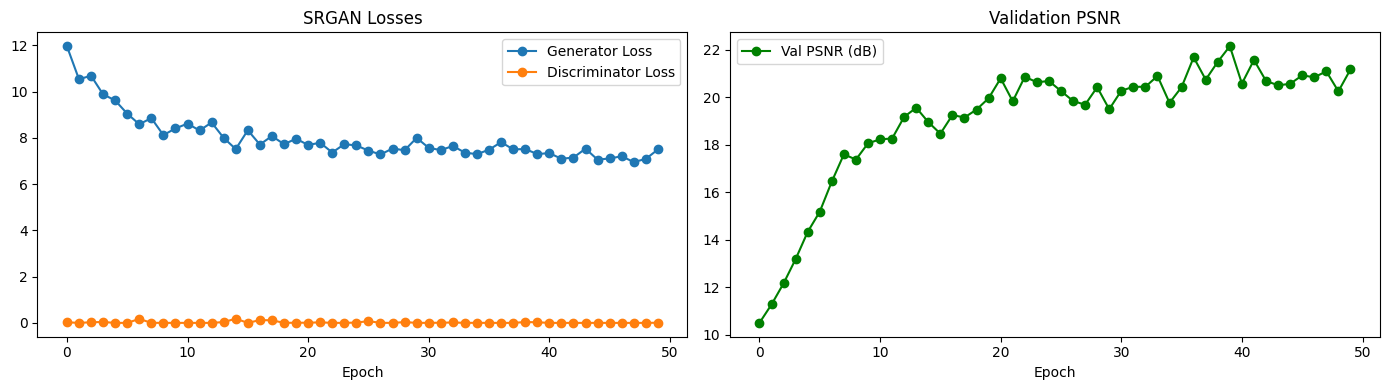

In [14]:
# ── Plot SRGAN training curves ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(sr_history['g_loss'], label='Generator Loss',     marker='o')
axes[0].plot(sr_history['d_loss'], label='Discriminator Loss', marker='o')
axes[0].set_title('SRGAN Losses'); axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(sr_history['val_psnr'], label='Val PSNR (dB)', marker='o', color='green')
axes[1].set_title('Validation PSNR'); axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout(); plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.058996927..0.7455323].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07129918..0.9907728].


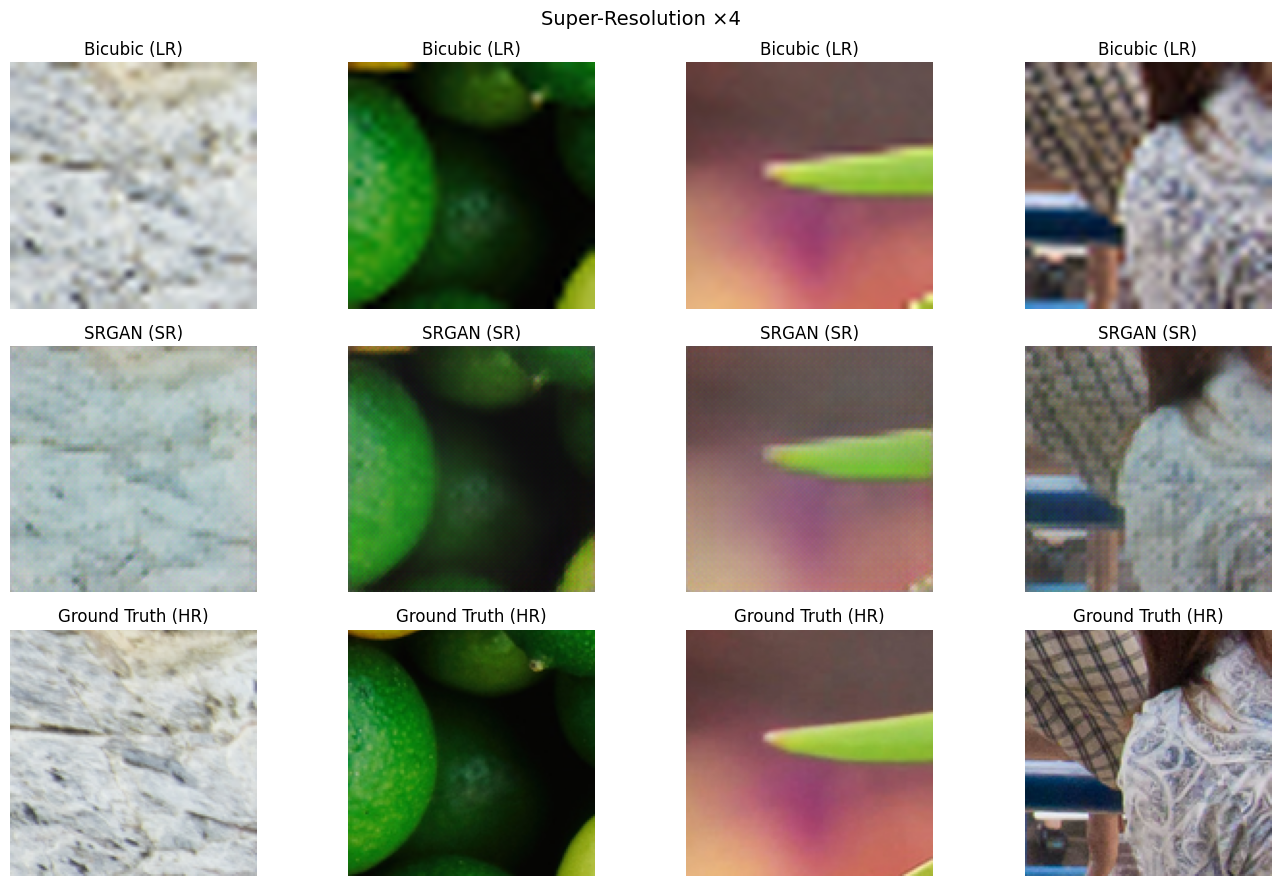

In [15]:
# ── Visualise super-resolution results ───────────────────────────────────────
gen.eval()
lr_batch, hr_batch = next(iter(val_sr_loader))
with torch.no_grad():
    sr_batch = gen(lr_batch.to(DEVICE)).cpu().clamp(0, 1)

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for i in range(4):
    # Upscale LR for visual comparison
    lr_up = F.interpolate(lr_batch[i:i+1], scale_factor=UPSCALE_FACTOR,
                          mode='bicubic', align_corners=False).squeeze(0)
    axes[0, i].imshow(lr_up.permute(1, 2, 0))
    axes[0, i].set_title('Bicubic (LR)'); axes[0, i].axis('off')
    axes[1, i].imshow(sr_batch[i].permute(1, 2, 0))
    axes[1, i].set_title('SRGAN (SR)'); axes[1, i].axis('off')
    axes[2, i].imshow(hr_batch[i].permute(1, 2, 0))
    axes[2, i].set_title('Ground Truth (HR)'); axes[2, i].axis('off')
plt.suptitle(f'Super-Resolution ×{UPSCALE_FACTOR}', fontsize=14)
plt.tight_layout(); plt.show()

---
## Save Model Checkpoints

In [16]:
torch.save(autoencoder.state_dict(), 'denoising_autoencoder.pth')
torch.save(gen.state_dict(),         'srgan_generator.pth')
torch.save(disc.state_dict(),        'srgan_discriminator.pth')
print('All model weights saved.')

All model weights saved.
